In [28]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
%matplotlib inline

In [29]:
path="/kaggle/input/potato/PlantVillage/"

In [30]:
image_size=256

In [31]:
data=tf.keras.preprocessing.image_dataset_from_directory(path,shuffle=True,image_size=(image_size,image_size),
                                        batch_size=32)

Found 2152 files belonging to 3 classes.


In [32]:
class_name=data.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [33]:
for x in class_name:
    length_of_class = len(x)
    print("=====================================")
    print(f"Length of {x}: {length_of_class}")

Length of Potato___Early_blight: 21
Length of Potato___Late_blight: 20
Length of Potato___healthy: 16


In [34]:
len(data)

68

In [35]:
for image,label in data.take(1):
    print(image.shape)
    print("========================================")
    print(label.numpy())

(32, 256, 256, 3)
[0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 1 2 2 0 0 0 2 1 1 0 0 1 1 1 0 1 1]


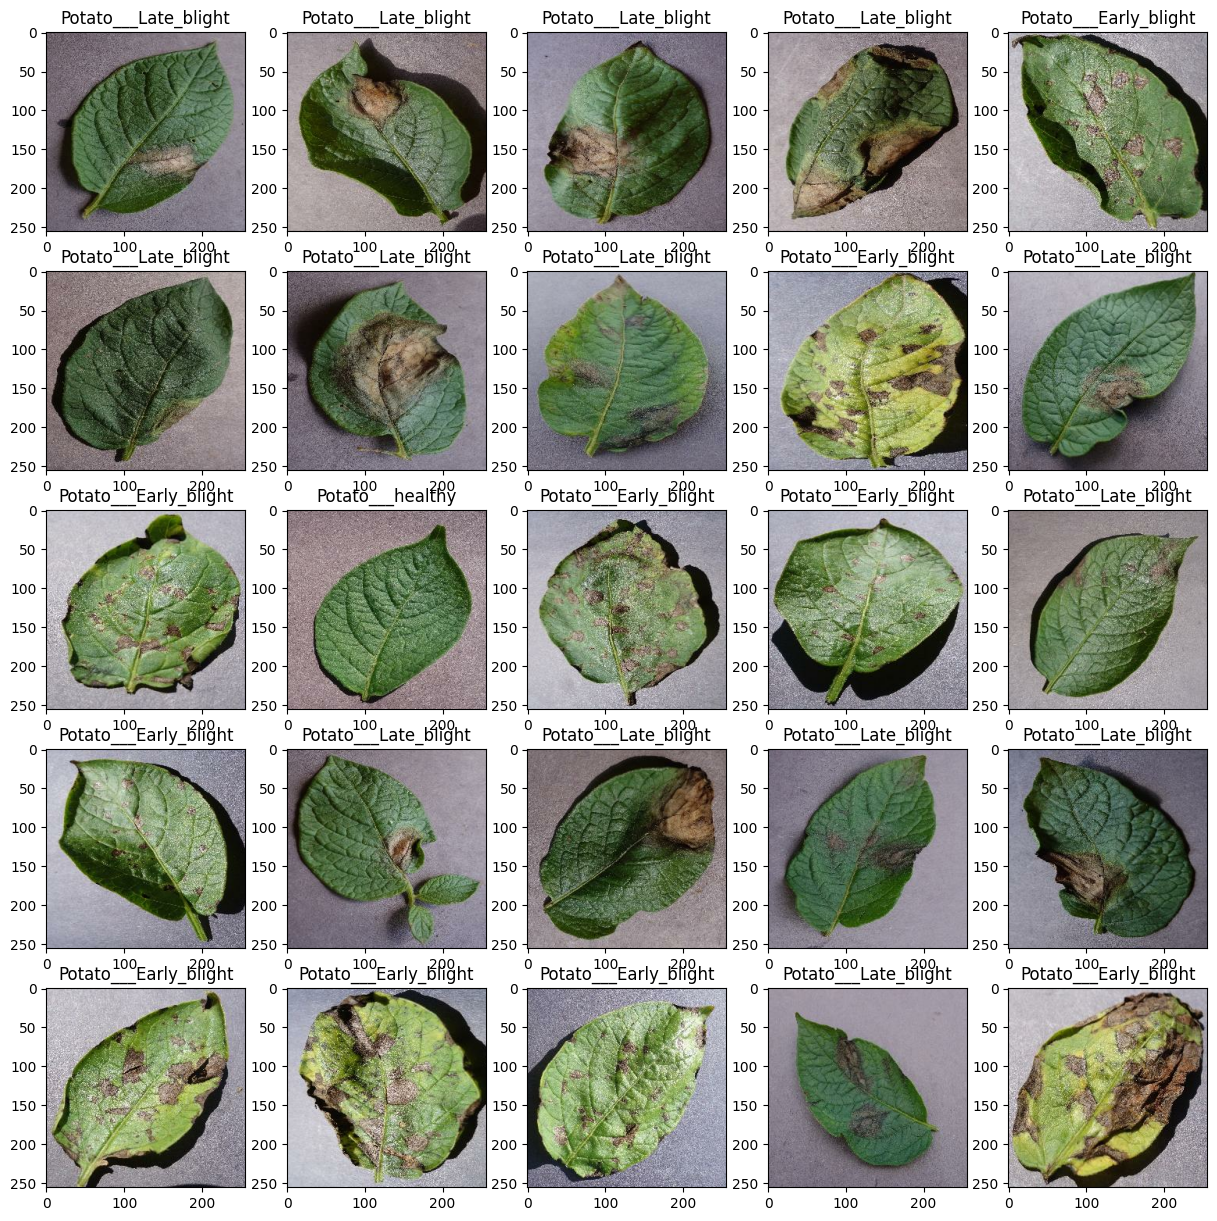

In [36]:
plt.figure(figsize=(15,15))
for image,label in data.take(1):
    for i in range(25):
        ax=plt.subplot(5,5,i+1)
        plt.imshow(image[i].numpy().astype("uint8"))
        plt.title(class_name[label[i]])
    plt.show()
   

In [37]:
train=data.take(54)
test=data.skip(54)
val=test.take(6)


In [38]:
train=train.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val=val.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test=test.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [39]:
resize_rescale=tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(image_size,image_size),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [40]:
data_augmentation=tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [41]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3


In [42]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)
model.compile(optimizer="adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=["accuracy"])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 conv2d_6 (Conv2D)           (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d_6 (MaxPoolin  (32, 127, 127, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPoolin  (32, 62, 62, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (32, 60, 60, 64)         

In [43]:
history=model.fit(train,epochs=30,batch_size=32,validation_data=val)

Epoch 1/30
54/54 [==============================] - 8s 58ms/step - loss: 0.8402 - accuracy: 0.6157 - val_loss: 0.6981 - val_accuracy: 0.7448
Epoch 2/30
54/54 [==============================] - 2s 35ms/step - loss: 0.6098 - accuracy: 0.7569 - val_loss: 0.6705 - val_accuracy: 0.6927
Epoch 3/30
54/54 [==============================] - 2s 35ms/step - loss: 0.5457 - accuracy: 0.7581 - val_loss: 0.4257 - val_accuracy: 0.7969
Epoch 4/30
54/54 [==============================] - 2s 35ms/step - loss: 0.4731 - accuracy: 0.8160 - val_loss: 0.2557 - val_accuracy: 0.9010
Epoch 5/30
54/54 [==============================] - 2s 35ms/step - loss: 0.3099 - accuracy: 0.8733 - val_loss: 0.3997 - val_accuracy: 0.8490
Epoch 6/30
54/54 [==============================] - 2s 35ms/step - loss: 0.3253 - accuracy: 0.8791 - val_loss: 0.5134 - val_accuracy: 0.8125
Epoch 7/30
54/54 [==============================] - 2s 35ms/step - loss: 0.3137 - accuracy: 0.8900 - val_loss: 0.1742 - val_accuracy: 0.9323
Epoch 8/30
54

In [44]:
model.evaluate(test)

14/14 [==============================] - 1s 15ms/step - loss: 0.9595 - accuracy: 0.9575


[0.9594564437866211, 0.9575471878051758]

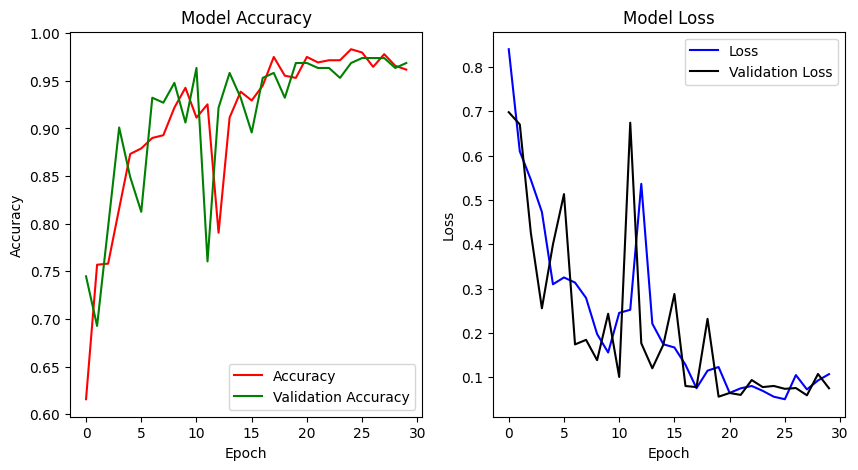

In [45]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# First subplot
ax[0].plot(history.history['accuracy'],label="Accuracy",color="red")
ax[0].plot(history.history['val_accuracy'],label="Validation Accuracy",color="green")
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='best')

# Second subplot
ax[1].plot(history.history['loss'],label="Loss",color="blue")
ax[1].plot(history.history['val_loss'],label="Validation Loss",color="black")
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='best')

plt.show()

1/1 [==============================] - 0s 128ms/step


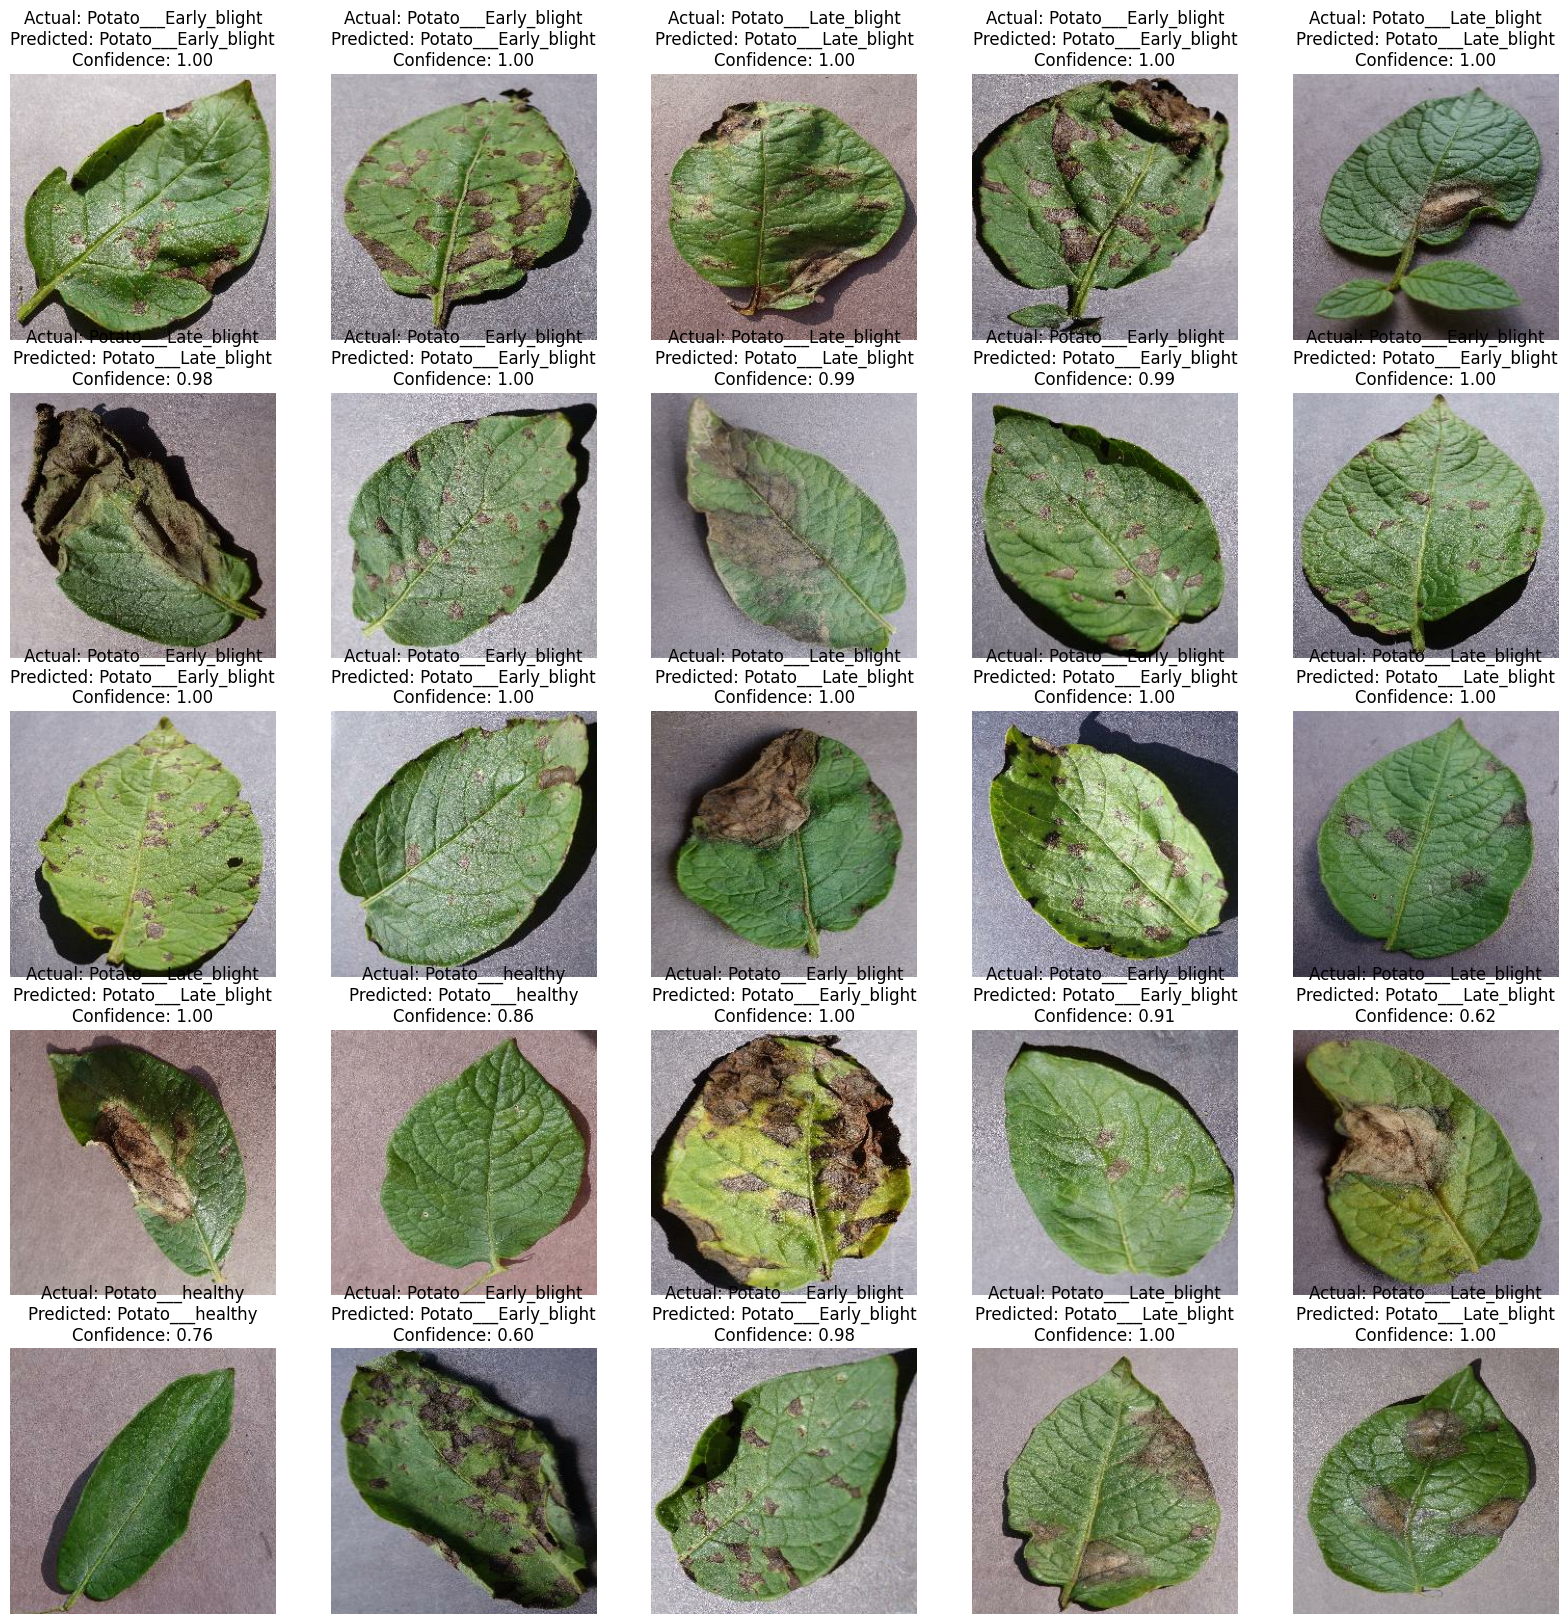

In [46]:
plt.figure(figsize=(20,20))
import numpy as np

for images, labels in test.take(1):
    predictions = model.predict(images)

 
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        actual_class = class_name[labels[i]]
        predicted_class = class_name[np.argmax(predictions[i])]
        confidence = np.max(predictions[i])

        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}")
        plt.axis("off")

    plt.show()



In [47]:
import joblib
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

model_version = 2
directory = "model"

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the model
joblib.dump(model, f"{directory}/model_version_{model_version}.joblib")


['model/model_version_2.joblib']

In [48]:
loaded_model = joblib.load(f"{directory}/model_version_{model_version}.joblib")

14/14 [==============================] - 0s 13ms/step


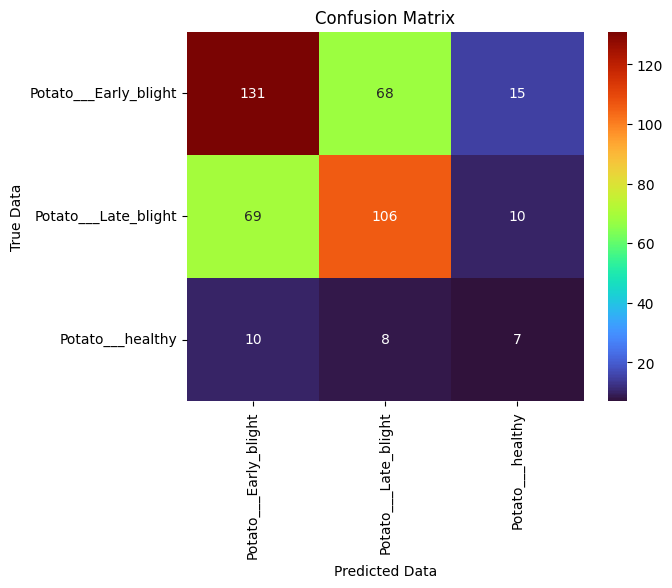

In [49]:
predictions = loaded_model.predict(test)
predict = np.argmax(predictions, axis=1)

true = np.concatenate([y for x, y in test], axis=0)
cm = confusion_matrix(true, predict)
sns.heatmap(cm,annot=True,fmt="d",cmap="turbo",xticklabels=class_name,yticklabels=class_name)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Data")
plt.ylabel("True Data")
plt.show()


In [50]:
print(classification_report(true,predict,target_names=class_name))

                       precision    recall  f1-score   support

Potato___Early_blight       0.62      0.61      0.62       214
 Potato___Late_blight       0.58      0.57      0.58       185
     Potato___healthy       0.22      0.28      0.25        25

             accuracy                           0.58       424
            macro avg       0.47      0.49      0.48       424
         weighted avg       0.58      0.58      0.58       424



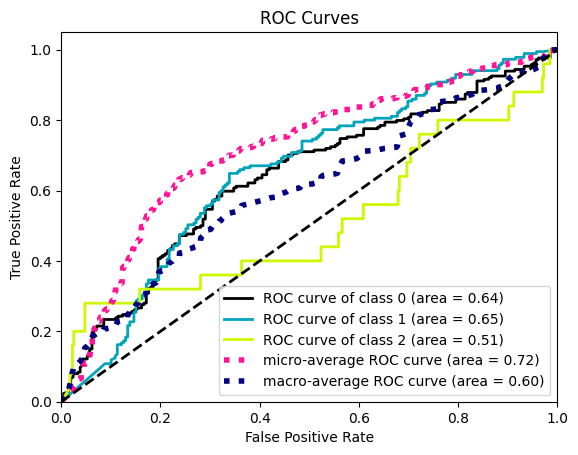

In [51]:
import scikitplot as skplt
skplt.metrics.plot_roc(true,predictions)
plt.show()

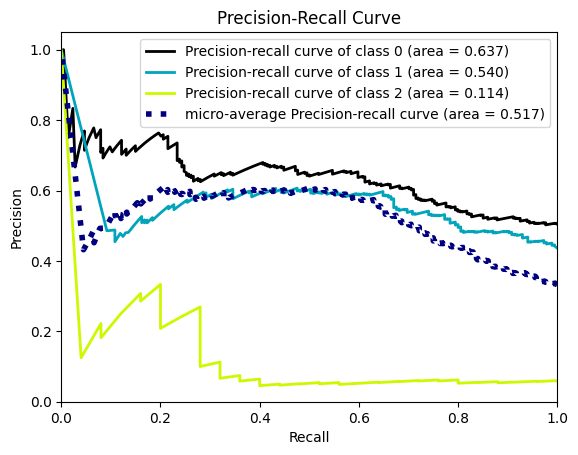

In [52]:
skplt.metrics.plot_precision_recall(true,predictions)
plt.show()

1/1 [==============================] - 0s 106ms/step


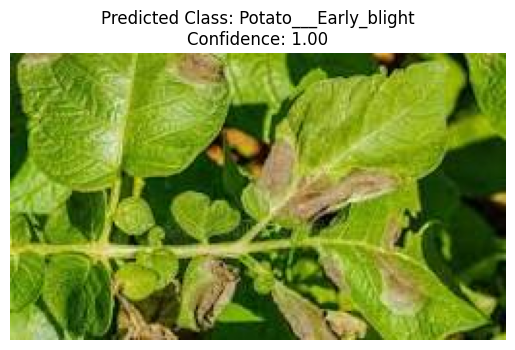

In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from io import BytesIO

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRkEY0UXJLItEspeP8APt232Uz8vS3SjYiAE4zJslJ-3Ro4n2SY1ghhDD_EWg&s"
response = requests.get(url)
img = cv2.imdecode(np.frombuffer(response.content, np.uint8), 1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
custom_image = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
custom_image = np.expand_dims(custom_image, axis=0)
custom_image = custom_image / 255.0
custom_prediction = model.predict(custom_image)
predicted_class = class_name[np.argmax(custom_prediction)]
confidence = np.max(custom_prediction)
plt.imshow(img)
plt.title(f"Predicted Class: {predicted_class}\nConfidence: {confidence:.2f}")
plt.axis("off")
plt.show()